# KOSPI 시장 탐색 — 01. 시드 데이터로 첫걸음

이 노트북은 세 가지를 한 번에 노린다.

1. **Python 개발자가 TypeScript/Deno 에 익숙해지기** — 코드 셀마다 Python 과 대조되는 지점을 짚는다.
2. **주식 초보가 개념을 데이터로 체감하기** — `docs/learning/stock-*.md` 에 정리된 개념을 실제 숫자로 확인한다.
3. **데이터를 시각화하고, 변수 간 관계를 살펴보기** — 등락률 분포, 시가총액과 등락률의 관계, 지수 흐름을 그려본다.

## 데이터 출처

이 프로젝트가 매일 갱신하는 실시간 API 대신, **저장소에 커밋된 시드 스냅샷**
(`src/data/*.json`)을 읽는다. 이유는 단순하다 — 노트북은 몇 달 뒤에 다시 열어도
**항상 같은 결과**가 나와야 학습에 쓸모가 있다. 시드는 며칠~몇 주 전 시점의 실제
KOSPI 데이터라 최신 시세는 아니지만, "분포를 보고 관계를 파악하는" 이 노트북의
목적에는 오히려 이 편이 낫다. 실시간 API 연동 상세는 [`docs/api-reference.md`](../docs/api-reference.md),
데이터 계층 구조는 [`docs/market-data.md`](../docs/market-data.md) 참고.

## 실행 방법

- JupyterLab 에서 이 파일(`notes/01-kospi-market-explorer.ipynb`)을 **`notes/` 폴더 안에서** 열어야 한다
  (커널의 작업 디렉터리가 노트북이 있는 폴더로 잡히기 때문 — `../src/data/...` 같은 상대경로가
  이걸 전제로 한다).
- 커널은 **Deno**를 선택한다.
- 첫 실행 시 `npm:d3`를 내려받느라 몇 초 걸릴 수 있다(`notes/deno.json`의 `nodeModulesDir: "auto"`
  덕분에 `notes/node_modules/`에만 격리되어 설치되고, 메인 Next.js 앱과는 무관하다).
- `deno jupyter` 커널은 Deno 스스로 "실험적(unstable)"이라 표시하는 기능이다. 드물게 차트가 그려진
  셀인데 출력이 비어 보일 때가 있다(전송 중 큰 메시지가 누락되는 알려진 문제) — **그 셀만 다시
  실행**하면 대부분 바로 나온다. 아래 차트 셀들이 `Deno.jupyter.svg` 같은 바로 표시되는 방식 대신
  `await Deno.jupyter.display(...)` 처럼 명시적으로 `await` 하는 것도 이 문제를 줄이기 위해서다.

## 1. Deno/TypeScript 워밍업 — Python 개발자를 위한 대조

Deno 커널 안에서는 `Deno.jupyter` 네임스페이스로 리치 출력(마크다운/HTML/SVG/이미지)을
그릴 수 있다. Python 의 `IPython.display` 와 같은 역할이다. `md`/`html`/`svg`/`image` 는
백틱을 붙여 쓰는 "태그드 템플릿 함수"라 `Deno.jupyter.md(str)` 처럼 괄호로 부르면 바로
에러가 난다 — 이 노트북에서는 대신 더 아래에 있는 `display()` 를 직접 쓴다(이유는 바로
위 "실행 방법"에 적어둔 안정성 때문).

In [1]:
console.log(Object.keys(Deno.jupyter));

[
  "broadcast", "display",
  "format",    "md",
  "html",      "svg",
  "image",     "$display"
]


**비동기 파일 읽기.** Python 은 `open(path).read()`로 동기 호출 한 줄이면 끝이지만,
Deno(그리고 브라우저/Node 계열 전반)는 파일 I/O 가 기본적으로 **비동기**다.
Jupyter 셀 최상위에서 바로 `await` 를 쓸 수 있다는 점도 짚을 만하다 — Python 도
IPython 최근 버전에서 top-level await 을 지원하긴 하지만, JS 진영에서는 이게 훨씬
오래된 관례다.

In [2]:
// Python: open("../package.json").read()[:40]
const raw = await Deno.readTextFile("../package.json");
console.log(raw.slice(0, 40));

{
  "name": "rokstock-01",
  "version": 


**배열 메서드 vs 리스트 컴프리헨션.** Python 의 `[x*2 for x in xs if x > 0]` 에 대응하는
JS 관용구는 메서드 체이닝이다: `xs.filter(x => x > 0).map(x => x * 2)`. 한 줄에 조건과
변환을 같이 쓰는 컴프리헨션과 달리, JS 는 각 단계를 별도 메서드로 쪼갠다 — 단계마다
중간 배열이 생기지만(성능이 중요하면 `reduce` 하나로 합칠 수 있다), 읽을 때는 파이프라인처럼
위에서 아래로 따라가기 좋다. 아래에서 바로 써먹는다.

In [3]:
const xs = [-2, -1, 0, 1, 2, 3];
const doubledPositives = xs.filter((x) => x > 0).map((x) => x * 2);
console.log(doubledPositives); // Python: [x*2 for x in xs if x > 0]

[ 2, 4, 6 ]


## 2. 시드 데이터 로드 & "필드헤더 + 튜플행" 언패킹

이 프로젝트의 시드 JSON 은 같은 키를 943번 반복하지 않으려고, `{fields: [...], rows: [[...], ...]}`
형태로 저장돼 있다(`docs/market-data.md` 참고). Python 이었다면
`pandas.DataFrame(rows, columns=fields)` 한 줄로 끝날 일이지만, 여기서는 pandas 없이
제네릭 함수 하나로 "행 배열"을 "객체 배열"로 직접 복원해본다 — 이 프로젝트의 실제 코드
(`src/lib/market/seed.ts`)도 같은 발상(열 이름 → 인덱스 맵)을 쓴다.

In [4]:
/** {fields, rows} 형태를 필드명 키를 가진 객체 배열로 복원한다. */
function rowsToObjects<Field extends string>(
  fields: readonly Field[],
  rows: readonly (string | number)[][],
): Record<Field, string | number>[] {
  return rows.map((row) => {
    const obj = {} as Record<Field, string | number>;
    fields.forEach((field, i) => {
      obj[field] = row[i];
    });
    return obj;
  });
}

const stockMasterJson = JSON.parse(await Deno.readTextFile("../src/data/stock-master.json"));
const snapshotJson = JSON.parse(await Deno.readTextFile("../src/data/market-snapshot.json"));
const indexJson = JSON.parse(await Deno.readTextFile("../src/data/index-kospi.json"));

console.log(`종목 마스터: ${stockMasterJson.rows.length}종목 (기준일 ${stockMasterJson.asOf})`);
console.log(`시세 스냅샷: ${snapshotJson.days.length}영업일치, 최신 = ${snapshotJson.days.at(-1).date}`);
console.log(`KOSPI 지수: ${indexJson.rows.length}일치`);

종목 마스터: 943종목 (기준일 2026-08-13)


시세 스냅샷: 5영업일치, 최신 = 2026-08-13


KOSPI 지수: 243일치


In [5]:
type Stock = { code: string; name: string; crno: string };
type Quote = {
  code: string;
  clpr: number; // 종가
  vs: number; // 전일 대비
  fltRt: number; // 등락률(%)
  mkp: number; // 시가
  hipr: number; // 고가
  lopr: number; // 저가
  trqu: number; // 거래량
  mrktTotAmt: number; // 시가총액
};

const stocks = rowsToObjects<keyof Stock>(stockMasterJson.fields, stockMasterJson.rows) as Stock[];
const codeToName = new Map(stocks.map((s) => [s.code, s.name]));

const latestDay = snapshotJson.days.at(-1);
const quotes = rowsToObjects<keyof Quote>(latestDay.fields, latestDay.rows) as Quote[];

console.log("첫 종목:", stocks[0]);
console.log("첫 시세:", quotes[0], "→", codeToName.get(quotes[0].code));

첫 종목: { code: "000020", name: "동화약품", crno: "1101110043870" }


첫 시세: {
  code: "000020",
  clpr: 5140,
  vs: -150,
  fltRt: -2.84,
  mkp: 5310,
  hipr: 5310,
  lopr: 5130,
  trqu: 122645,
  mrktTotAmt: 143567755800
} → 동화약품


**필드명 사전.** `주식시세정보` API 필드는 줄임말이라 처음엔 낯설다(`docs/api-reference.md` 1절 참고).

| 필드 | 뜻 | 필드 | 뜻 |
|---|---|---|---|
| `clpr` | 종가 | `hipr` | 고가 |
| `vs` | 전일 대비 | `lopr` | 저가 |
| `fltRt` | 등락률(%) | `trqu` | 거래량 |
| `mkp` | 시가 | `mrktTotAmt` | 시가총액 |

## 3. 시장 스냅샷 탐색 — 시장 폭(market breadth)

개별 종목 하나가 아니라 **시장 전체가 오늘 어떤 기분이었는지**를 보는 지표를 시장 폭이라
부른다. 상승 종목 수가 하락 종목 수보다 압도적으로 많으면, 지수 자체는 몇몇 대형주가
끌어올린 것처럼 보여도 "시장 전반이 좋았다"고 말할 수 있다 — 반대의 경우(소수 대형주만
상승, 대다수는 하락)도 실제로 자주 나온다. 관련 개념: [`stock-benchmark-index.md`](../docs/learning/stock-benchmark-index.md).

In [6]:
const up = quotes.filter((q) => q.fltRt > 0).length;
const down = quotes.filter((q) => q.fltRt < 0).length;
const flat = quotes.length - up - down;

const breadthMd = `
### ${latestDay.date} 시장 폭

| 상승 | 하락 | 보합 | 합계 |
|---|---|---|---|
| 🔴 ${up} | 🔵 ${down} | ⚪ ${flat} | ${quotes.length} |
`;
await Deno.jupyter.display({ "text/markdown": breadthMd }, { raw: true });


### 2026-08-13 시장 폭

| 상승 | 하락 | 보합 | 합계 |
|---|---|---|---|
| 🔴 333 | 🔵 533 | ⚪ 76 | 942 |


In [7]:
function topByRate(qs: Quote[], n: number, dir: "up" | "down") {
  const sorted = [...qs].sort((a, b) => (dir === "up" ? b.fltRt - a.fltRt : a.fltRt - b.fltRt));
  return sorted.slice(0, n);
}

function toMdRows(qs: Quote[]) {
  return qs
    .map((q) => `| ${codeToName.get(q.code) ?? q.code} | ${q.fltRt > 0 ? "+" : ""}${q.fltRt}% | ${q.clpr.toLocaleString("ko-KR")} |`)
    .join("\n");
}

const gainers = topByRate(quotes, 10, "up");
const losers = topByRate(quotes, 10, "down");

const rankingMd = `
**상승률 상위 10**

| 종목 | 등락률 | 종가 |
|---|---|---|
${toMdRows(gainers)}

**하락률 상위 10**

| 종목 | 등락률 | 종가 |
|---|---|---|
${toMdRows(losers)}
`;
await Deno.jupyter.display({ "text/markdown": rankingMd }, { raw: true });


**상승률 상위 10**

| 종목 | 등락률 | 종가 |
|---|---|---|
| 금호전기 | +30% | 6,890 |
| 미래산업 | +19.37% | 10,230 |
| 삼화콘덴서 | +17.39% | 103,300 |
| 삼성전기 | +12.58% | 1,503,000 |
| 자화전자 | +11.42% | 30,250 |
| 미원에스씨 | +9.99% | 132,100 |
| 삼성전기우 | +9.96% | 508,000 |
| 금호타이어 | +9.7% | 8,140 |
| 대동 | +9.42% | 8,480 |
| 후성 | +9.22% | 11,960 |

**하락률 상위 10**

| 종목 | 등락률 | 종가 |
|---|---|---|
| 금호건설우 | -14.04% | 24,500 |
| 에이블씨엔씨 | -10.13% | 12,070 |
| 달바글로벌 | -9.92% | 236,000 |
| 유니퀘스트 | -9.18% | 6,630 |
| 사조씨푸드 | -8% | 9,320 |
| 아이에스동서 | -7.88% | 18,000 |
| 유니켐 | -7.7% | 4,855 |
| 토니모리 | -7.2% | 5,800 |
| 광동제약 | -6.75% | 6,220 |
| 한국전력 | -6.63% | 33,100 |


등락률 전체 **분포**도 봐두면 좋다 — 위 표는 극단값(1등 10등)만 보여주지만, 히스토그램은
"대다수 종목이 어디쯤 몰려 있는지"를 보여준다.

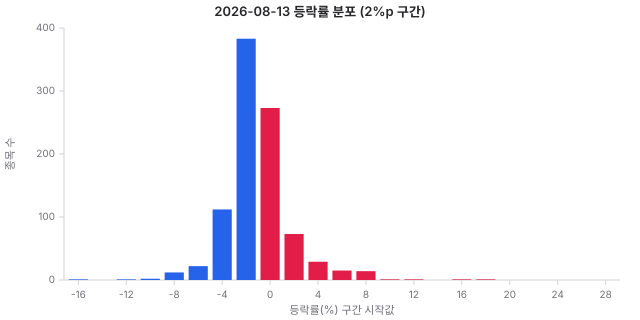

In [8]:
import { renderBarChart, COLORS } from "./lib/chart.ts";

/** 값을 binSize 간격 구간으로 나눠 구간별 개수를 센다. */
function bucketize(values: number[], binSize: number) {
  const min = Math.floor(Math.min(...values) / binSize) * binSize;
  const max = Math.ceil(Math.max(...values) / binSize) * binSize;
  const bins: { label: string; value: number; lo: number }[] = [];
  for (let lo = min; lo < max; lo += binSize) {
    const count = values.filter((v) => v >= lo && v < lo + binSize).length;
    bins.push({ label: `${lo}`, value: count, lo });
  }
  return bins;
}

const rates = quotes.map((q) => q.fltRt);
const bins = bucketize(rates, 2);

const histogramSvg = renderBarChart(bins, {
  title: `${latestDay.date} 등락률 분포 (2%p 구간)`,
  xLabel: "등락률(%) 구간 시작값",
  yLabel: "종목 수",
  color: (b: { label: string; value: number; lo?: number }) => ((b as { lo: number }).lo >= 0 ? COLORS.up : COLORS.down),
});

await Deno.jupyter.display({ "image/svg+xml": histogramSvg }, { raw: true });

## 4. 시가총액과 등락률의 관계

"대형주가 더 안정적이고, 소형주는 변동성이 크다"는 말을 자주 듣는다. 시가총액 기준으로
종목을 3등분해서 실제로 그런지 확인해본다.

In [9]:
const withCap = quotes.filter((q) => q.mrktTotAmt > 0);
const byCapDesc = [...withCap].sort((a, b) => b.mrktTotAmt - a.mrktTotAmt);
const third = Math.floor(byCapDesc.length / 3);

const large = byCapDesc.slice(0, third);
const mid = byCapDesc.slice(third, third * 2);
const small = byCapDesc.slice(third * 2);

const avgRate = (qs: Quote[]) => qs.reduce((sum, q) => sum + q.fltRt, 0) / qs.length;
const stdRate = (qs: Quote[]) => {
  const m = avgRate(qs);
  return Math.sqrt(qs.reduce((sum, q) => sum + (q.fltRt - m) ** 2, 0) / qs.length);
};

const capStatsMd = `
| 구간 | 종목 수 | 평균 등락률 | 등락률 표준편차(변동성) |
|---|---|---|---|
| 대형주 (시총 상위 1/3) | ${large.length} | ${avgRate(large).toFixed(2)}% | ${stdRate(large).toFixed(2)}%p |
| 중형주 | ${mid.length} | ${avgRate(mid).toFixed(2)}% | ${stdRate(mid).toFixed(2)}%p |
| 소형주 (시총 하위 1/3) | ${small.length} | ${avgRate(small).toFixed(2)}% | ${stdRate(small).toFixed(2)}%p |
`;
await Deno.jupyter.display({ "text/markdown": capStatsMd }, { raw: true });


| 구간 | 종목 수 | 평균 등락률 | 등락률 표준편차(변동성) |
|---|---|---|---|
| 대형주 (시총 상위 1/3) | 314 | 0.86% | 3.18%p |
| 중형주 | 314 | -0.75% | 2.50%p |
| 소형주 (시총 하위 1/3) | 314 | -0.27% | 2.78%p |


표만으로는 "구간 안에서 얼마나 흩어져 있는지"가 안 보인다. 종목 하나하나를 점으로
찍어보면 구간 평균 뒤에 숨은 개별 종목들의 편차가 드러난다. 시가총액은 몇백억 원부터
수백조 원까지 자릿수가 크게 차이 나서, x축을 **로그 스케일**로 그린다.

942종목을 다 찍으면 점이 서로 겹쳐 오히려 안 보인다 — 시가총액 순위로 고르게
표본을 뽑아서(대형주부터 소형주까지 골고루) 그린다. Python 이었다면
`df.iloc[::stride]` 에 해당하는, 일정 간격으로 건너뛰며 뽑는 방식이다.

942종목 중 236종목 표본(시총 순위 4개마다 1개)


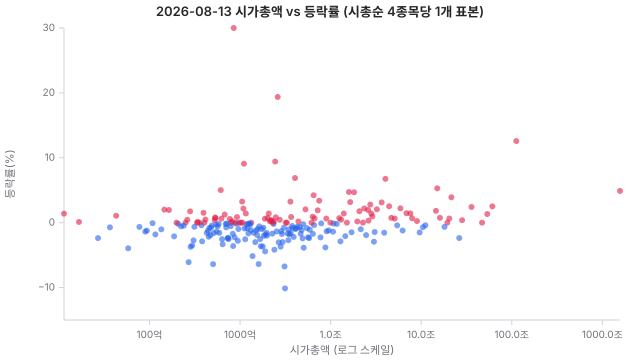

In [10]:
import { renderScatterChart } from "./lib/chart.ts";

// src/lib/market/format.ts 의 formatKrwCompact 와 같은 발상(조/억 단위) —
// d3 기본 SI 접두어("~s")로 그리면 삼성전자 같은 초대형주가 "1P"(페타, 10^15)로 나와
// 국내 증시에 익숙한 조/억 단위보다 오히려 낯설다.
function krwCompact(won: number): string {
  const abs = Math.abs(won);
  if (abs >= 1_0000_0000_0000) return `${(won / 1_0000_0000_0000).toFixed(1)}조`;
  if (abs >= 1_0000_0000) return `${Math.round(won / 1_0000_0000)}억`;
  return String(won);
}

const byCapForSample = [...withCap].sort((a, b) => b.mrktTotAmt - a.mrktTotAmt);
const sampleSize = 300;
const stride = Math.ceil(byCapForSample.length / sampleSize);
const sampled = byCapForSample.filter((_, i) => i % stride === 0);
console.log(`${byCapForSample.length}종목 중 ${sampled.length}종목 표본(시총 순위 ${stride}개마다 1개)`);

const scatterSvg = renderScatterChart(
  sampled.map((q) => ({ x: q.mrktTotAmt, y: q.fltRt })),
  {
    title: `${latestDay.date} 시가총액 vs 등락률 (시총순 ${stride}종목당 1개 표본)`,
    xLabel: "시가총액 (로그 스케일)",
    yLabel: "등락률(%)",
    xLog: true,
    xTickFormat: krwCompact,
    color: (p: { y: number }) => (p.y >= 0 ? COLORS.up : COLORS.down),
  },
);

await Deno.jupyter.display({ "image/svg+xml": scatterSvg }, { raw: true });

## 5. KOSPI 지수 1년 흐름

개별 종목이 아니라 **시장 전체를 대표하는 하나의 숫자**가 지수다 — 오늘 산 종목이
올랐는지보다 "시장 평균과 비교해 잘했는지"를 판단하는 벤치마크 역할을 한다
([`stock-benchmark-index.md`](../docs/learning/stock-benchmark-index.md)).

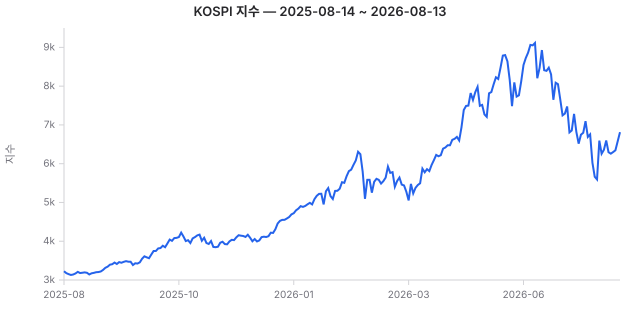

In [11]:
type IndexPoint = { date: string; clpr: number; vs: number; fltRt: number };
const indexRows = rowsToObjects<keyof IndexPoint>(indexJson.fields, indexJson.rows) as IndexPoint[];

import { renderLineChart } from "./lib/chart.ts";

const dateAt = (i: number) => indexRows[Math.round(i)]?.date ?? "";
const lineSvg = renderLineChart(
  indexRows.map((r, i) => ({ x: i, y: r.clpr })),
  {
    title: `KOSPI 지수 — ${indexRows[0].date} ~ ${indexRows.at(-1)!.date}`,
    yLabel: "지수",
    xTickFormat: (i: number) => dateAt(i).slice(0, 7), // "YYYY-MM"
  },
);

await Deno.jupyter.display({ "image/svg+xml": lineSvg }, { raw: true });

In [12]:
const biggestMoves = [...indexRows].sort((a, b) => Math.abs(b.fltRt) - Math.abs(a.fltRt)).slice(0, 5);

const movesMd = `
**최근 1년 중 등락폭이 가장 컸던 5일**

| 날짜 | 종가 | 등락률 |
|---|---|---|
${biggestMoves.map((r) => `| ${r.date} | ${r.clpr.toLocaleString("ko-KR")} | ${r.fltRt > 0 ? "+" : ""}${r.fltRt}% |`).join("\n")}
`;
await Deno.jupyter.display({ "text/markdown": movesMd }, { raw: true });


**최근 1년 중 등락폭이 가장 컸던 5일**

| 날짜 | 종가 | 등락률 |
|---|---|---|
| 2026-07-31 | 6,595.45 | +17.91% |
| 2026-03-04 | 5,093.54 | -12.06% |
| 2026-07-28 | 6,023.66 | -10.84% |
| 2026-06-23 | 8,203.84 | -9.99% |
| 2026-03-05 | 5,583.9 | +9.63% |


## 다음 걸음

이 노트북은 커밋된 시드(며칠~몇 주 전 스냅샷)만 썼다 — 오프라인에서도 항상 같은 결과가
나오게 하기 위해서다. 앞으로 이어갈 계획은 [`notes/README.md`](./README.md)에 정리해뒀다:

- **02** — 재무제표로 PER/PBR 계산, 가치주 스크리닝
- **03** — 실 API로 종목 하나의 1년 일봉을 받아 캔들·이동평균 (`DATA_GO_KR_SERVICE_KEY` 사용)
- **04** — 배당수익률 분포, 수수료·세금이 수익률에 미치는 영향 시뮬레이션

개념을 더 찬찬히 읽고 싶다면 [`docs/learning/`](../docs/learning/README.md)의 `stock-*.md` 문서들을 참고.